── Jacobians ──────────────────────
J_front:


Matrix([
[1, 0,  l*(sin(a1(t) + theta(t)) + sin(theta(t)))/2,  l*sin(a1(t) + theta(t))/2, 0],
[0, 1, -l*(cos(a1(t) + theta(t)) + cos(theta(t)))/2, -l*cos(a1(t) + theta(t))/2, 0]])

J_tail:


Matrix([
[1, 0, -l*(sin(a2(t) + theta(t)) + sin(theta(t)))/2, 0, -l*sin(a2(t) + theta(t))/2],
[0, 1,  l*(cos(a2(t) + theta(t)) + cos(theta(t)))/2, 0,  l*cos(a2(t) + theta(t))/2]])


── Mass matrix M(q) ────────────────


Matrix([
[                                                  3*m,                                                      0,    l*m*(sin(a1(t) + theta(t)) - sin(a2(t) + theta(t)))/2,        l*m*sin(a1(t) + theta(t))/2,       -l*m*sin(a2(t) + theta(t))/2],
[                                                    0,                                                    3*m,   l*m*(-cos(a1(t) + theta(t)) + cos(a2(t) + theta(t)))/2,       -l*m*cos(a1(t) + theta(t))/2,        l*m*cos(a2(t) + theta(t))/2],
[l*m*(sin(a1(t) + theta(t)) - sin(a2(t) + theta(t)))/2, l*m*(-cos(a1(t) + theta(t)) + cos(a2(t) + theta(t)))/2, 3*I + l**2*m*cos(a1(t))/2 + l**2*m*cos(a2(t))/2 + l**2*m, I + l**2*m*cos(a1(t))/4 + l**2*m/4, I + l**2*m*cos(a2(t))/4 + l**2*m/4],
[                          l*m*sin(a1(t) + theta(t))/2,                           -l*m*cos(a1(t) + theta(t))/2,                       I + l**2*m*cos(a1(t))/4 + l**2*m/4,                       I + l**2*m/4,                                  0],
[                  


── Coriolis vector h(q,q_dot) ──────


Matrix([
[l*m*(cos(a1(t) + theta(t))*Derivative(a1(t), t)**2 + 2*cos(a1(t) + theta(t))*Derivative(a1(t), t)*Derivative(theta(t), t) + cos(a1(t) + theta(t))*Derivative(theta(t), t)**2 - cos(a2(t) + theta(t))*Derivative(a2(t), t)**2 - 2*cos(a2(t) + theta(t))*Derivative(a2(t), t)*Derivative(theta(t), t) - cos(a2(t) + theta(t))*Derivative(theta(t), t)**2)/2],
[l*m*(sin(a1(t) + theta(t))*Derivative(a1(t), t)**2 + 2*sin(a1(t) + theta(t))*Derivative(a1(t), t)*Derivative(theta(t), t) + sin(a1(t) + theta(t))*Derivative(theta(t), t)**2 - sin(a2(t) + theta(t))*Derivative(a2(t), t)**2 - 2*sin(a2(t) + theta(t))*Derivative(a2(t), t)*Derivative(theta(t), t) - sin(a2(t) + theta(t))*Derivative(theta(t), t)**2)/2],
[                                                                                                                                              -l**2*m*(sin(a1(t))*Derivative(a1(t), t)**2 + 2*sin(a1(t))*Derivative(a1(t), t)*Derivative(theta(t), t) + sin(a2(t))*Derivative(a2(t), t)**2 + 2*sin(a


── Q_flow (anisotropic drag) computed ──────────────

Symbolic derivation complete.

── Gait turning diagnostic (3 cycles from rest, no flow) ───────────
  swim        : Δx=-0.7136 m  Δy=-0.2506 m  Δθ=+4.66°  (per 3 cycles)
  turn_pos    : Δx=+0.2057 m  Δy=-0.0572 m  Δθ=+9.03°  (per 3 cycles)
  turn_neg    : Δx=+0.0403 m  Δy=+0.1052 m  Δθ=+2.99°  (per 3 cycles)

  → GAIT_CW  = 'turn_neg'  (Δθ = +1.00°/cycle)
  → GAIT_CCW = 'turn_pos'  (Δθ = +3.01°/cycle)

Scenario A: no disturbance…
Scenario B: Uy=0.4 m/s, t∈[3,8] s…
Scenario C: two opposing pulses…

Final y: A=-0.6396 m  B=0.0403 m  C=-0.4190 m


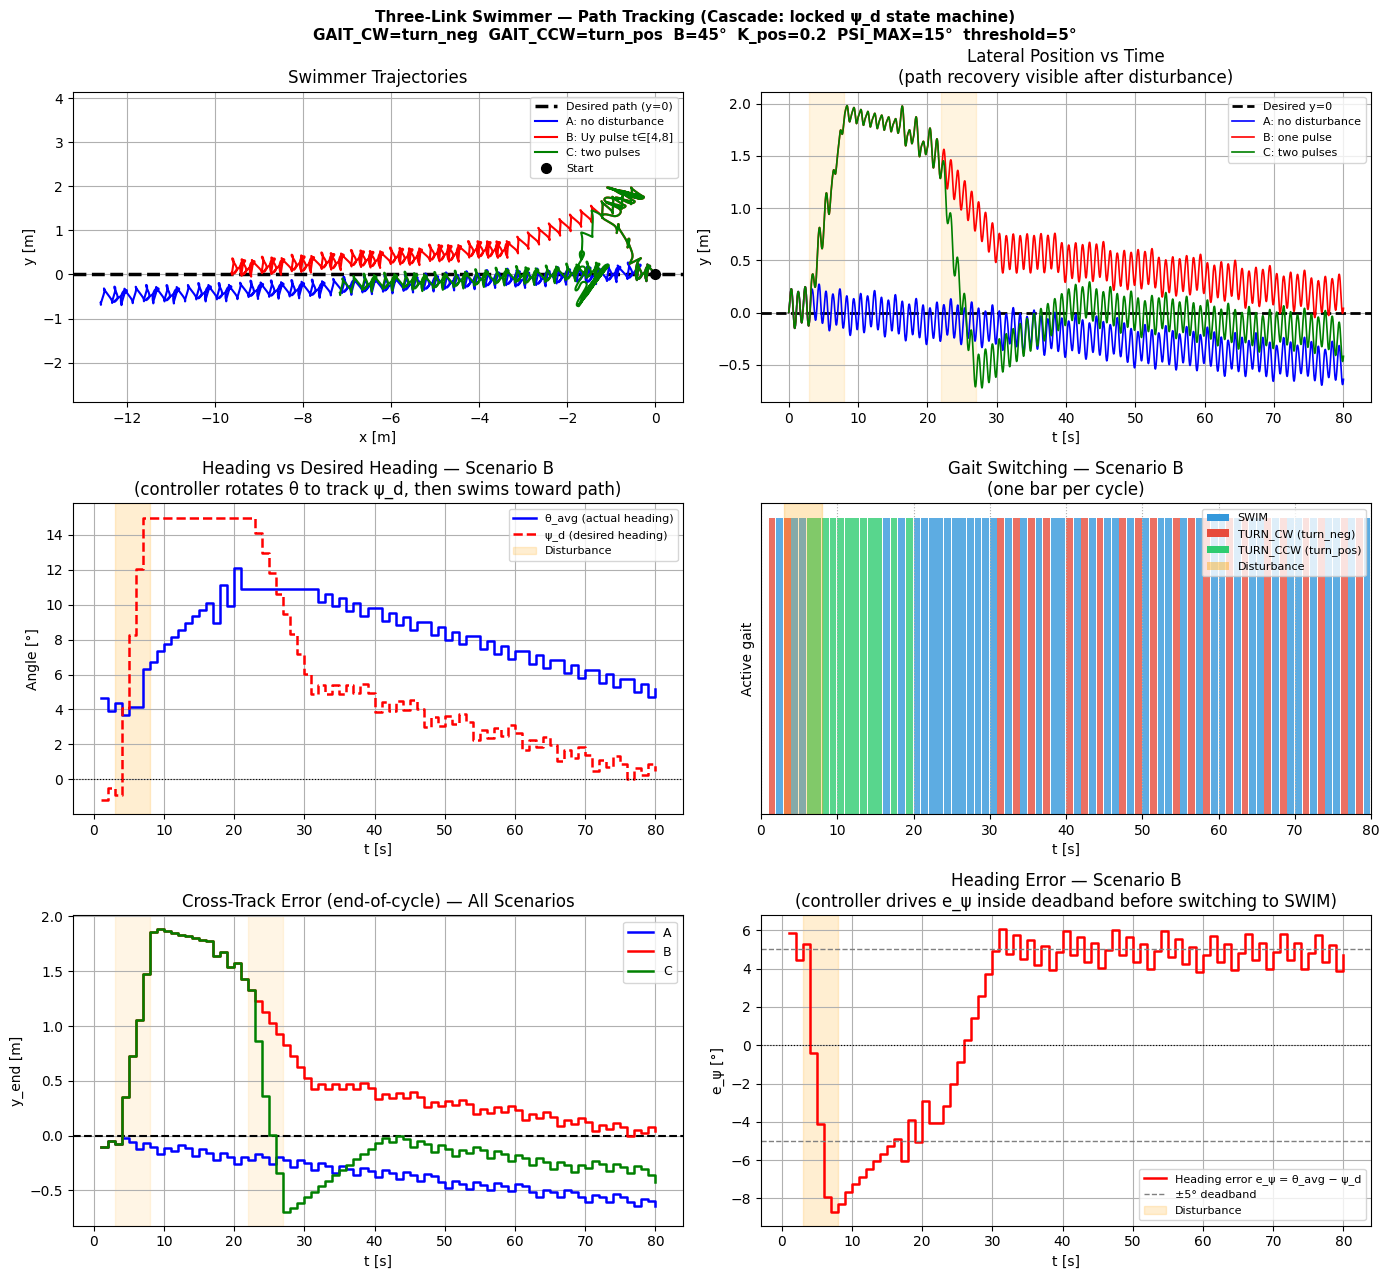


Done. Plot saved to path_tracking_gait_switching.png


In [4]:
"""
Three-Link Swimmer — Path Tracking with Gait Switching
=======================================================

CASCADE CONTROLLER  (corrected architecture)
--------------------------------------------

  y_end  (cross-track error at end of cycle)
      ↓
  Desired heading:   ψ_d = K_pos · y_end      [rad]
      (fish above path → tilt body CCW so swim direction has −y component)
      ↓
  Heading error:     e_ψ = θ_avg − ψ_d
      ↓
  Gait selector:
      e_ψ > +THRESH  →  TURN_CW  gait  (decrease θ)
      e_ψ < −THRESH  →  TURN_CCW gait  (increase θ)
      otherwise      →  SWIM     gait
      ↓
  3-Link Swimmer  (one full gait cycle, then repeat)
      ↑
  Disturbance  (known cross-flow)

Why this works
--------------
Swimming direction in world frame = R_z(θ) @ [−1, 0] = (−cos θ, −sin θ).
When θ > 0 (CCW tilt) the y-component is −sin θ < 0, so the fish swims
toward −y.  A fish above the path (y > 0) therefore needs θ > 0 to point
itself back toward y = 0.

Previous attempt used position → δ directly, which skips heading entirely.
A fish cannot sidestep; it must first rotate its heading, then swim.

Gait library
------------
SWIM:     α₁ = A·sin(ωt),        α₂ = A·sin(ωt + π/2)   symmetric propulsion
TURN_POS: α₁ = +B + A·sin(ωt),   α₂ = +B + A·sin(ωt + π/2)
TURN_NEG: α₁ = −B + A·sin(ωt),   α₂ = −B + A·sin(ωt + π/2)

Diagnostic at startup simulates 3 cycles of each gait and measures
net Δθ.  GAIT_CW / GAIT_CCW are assigned automatically.
"""

from sympy import *
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

# ─────────────────────────────────────────────────────────────────────────────
# 1.  SYMBOLIC VARIABLES
# ─────────────────────────────────────────────────────────────────────────────
t = symbols("t", real=True)
l, m, I_link, c_t, c_n = symbols("l m I c_t c_n", positive=True, real=True)
U_flow   = symbols("U_flow",   real=True)
U_flow_y = symbols("U_flow_y", real=True)

x     = Function("x")(t)
y     = Function("y")(t)
theta = Function("theta")(t)
a1    = Function("a1")(t)
a2    = Function("a2")(t)

q    = [x, y, theta, a1, a2]
q_dt = [diff(v, t) for v in q]
n    = 5

# ─────────────────────────────────────────────────────────────────────────────
# 2.  SE(3) HELPERS
# ─────────────────────────────────────────────────────────────────────────────
def R_z(ang):
    return Matrix([[cos(ang), -sin(ang), 0],
                   [sin(ang),  cos(ang), 0],
                   [0,         0,        1]])

def make_T(R, p):
    return Matrix([
        [R[0,0], R[0,1], R[0,2], p[0,0]],
        [R[1,0], R[1,1], R[1,2], p[1,0]],
        [R[2,0], R[2,1], R[2,2], p[2,0]],
        [0,      0,      0,      1      ]
    ])

# ─────────────────────────────────────────────────────────────────────────────
# 3.  LINK TRANSFORMS   [Front] --α₁-- [Base] --α₂-- [Tail]
# ─────────────────────────────────────────────────────────────────────────────
T_base  = make_T(R_z(theta), Matrix([[x], [y], [0]]))
T_front = (T_base
           @ make_T(Matrix.eye(3), Matrix([[-l/2], [0], [0]]))
           @ make_T(R_z(a1),       Matrix([[0],    [0], [0]]))
           @ make_T(Matrix.eye(3), Matrix([[-l/2], [0], [0]])))
T_tail  = (T_base
           @ make_T(Matrix.eye(3), Matrix([[l/2], [0], [0]]))
           @ make_T(R_z(a2),       Matrix([[0],   [0], [0]]))
           @ make_T(Matrix.eye(3), Matrix([[l/2], [0], [0]])))

# ─────────────────────────────────────────────────────────────────────────────
# 4.  LINK POSITIONS AND TRANSLATIONAL JACOBIANS
# ─────────────────────────────────────────────────────────────────────────────
r_base  = Matrix([T_base[0, 3],  T_base[1, 3]])
r_front = simplify(Matrix([T_front[0, 3], T_front[1, 3]]))
r_tail  = simplify(Matrix([T_tail[0,  3], T_tail[1,  3]]))

J_base  = r_base.jacobian(q)
J_front = simplify(r_front.jacobian(q))
J_tail  = simplify(r_tail.jacobian(q))

print("── Jacobians ──────────────────────")
print("J_front:"); display(J_front)
print("J_tail:");  display(J_tail)

# ─────────────────────────────────────────────────────────────────────────────
# 5.  KINETIC ENERGY AND MASS MATRIX
# ─────────────────────────────────────────────────────────────────────────────
qd = Matrix(q_dt)

def link_KE(J_v, omega_sym):
    v = J_v @ qd
    return Rational(1,2)*m*(v.T @ v)[0,0] + Rational(1,2)*I_link*omega_sym**2

T_kin = expand(
    link_KE(J_base,  q_dt[2])            +
    link_KE(J_front, q_dt[2] + q_dt[3]) +
    link_KE(J_tail,  q_dt[2] + q_dt[4])
)

M_mat = simplify(Matrix([
    [diff(diff(T_kin, q_dt[i]), q_dt[j]) for j in range(n)]
    for i in range(n)
]))

print("\n── Mass matrix M(q) ────────────────"); display(M_mat)

# ─────────────────────────────────────────────────────────────────────────────
# 6.  CORIOLIS / CENTRIFUGAL VECTOR
# ─────────────────────────────────────────────────────────────────────────────
q_ddt_syms = symbols("xdd ydd thdd a1dd a2dd")
h_vec = Matrix.zeros(n, 1)
for i in range(n):
    dT_i  = diff(T_kin, q_dt[i])
    ddt_i = sum(
        diff(dT_i, q[j])    * q_dt[j] +
        diff(dT_i, q_dt[j]) * q_ddt_syms[j]
        for j in range(n)
    )
    h_vec[i] = simplify(
        ddt_i.subs(dict(zip(q_ddt_syms, [0]*n))) - diff(T_kin, q[i])
    )

print("\n── Coriolis vector h(q,q_dot) ──────"); display(h_vec)

# ─────────────────────────────────────────────────────────────────────────────
# 7.  FLOW FIELD AND GENERALISED HYDRODYNAMIC FORCES
#
#   ANISOTROPIC (resistive-force) DRAG
#   -----------------------------------
#   Each link resists motion NORMAL to its own body axis (c_n) more than
#   motion ALONG its body axis (c_t), with c_n > c_t -- exactly like a real
#   fish/foil. The relative flow velocity of each link's centroid is rotated
#   into that link's body frame, scaled by diag(c_t, c_n), then rotated back.
#
#   This anisotropy is what allows the symmetric "swim" gait to produce NET
#   forward thrust. With ISOTROPIC drag (c_t == c_n, the original model) the
#   drag force is just -c*v_rel regardless of orientation, and the symmetric
#   swim gait settles into a closed periodic orbit in (x,y,theta) -- i.e.
#   ZERO net displacement per cycle ("doesn't move").
# ─────────────────────────────────────────────────────────────────────────────
def flow_field(px, py):
    return Matrix([U_flow, U_flow_y])

def generalized_drag_force(J_v, r_i, phi_i):
    """Anisotropic drag force for one link, mapped to generalised forces.

    phi_i : link's absolute orientation angle (world frame)
    """
    vf_i = flow_field(r_i[0], r_i[1])
    vrel = J_v @ qd - vf_i                       # world-frame relative velocity

    R_to_body = Matrix([[ cos(phi_i), sin(phi_i)],
                         [-sin(phi_i), cos(phi_i)]])   # R(phi_i)^T
    v_local = R_to_body @ vrel

    F_local = -Matrix([[c_t, 0], [0, c_n]]) @ v_local   # anisotropic drag

    R_to_world = Matrix([[cos(phi_i), -sin(phi_i)],
                          [sin(phi_i),  cos(phi_i)]])  # R(phi_i)
    F_world = R_to_world @ F_local
    return J_v.T @ F_world

# Absolute orientation of each link (world frame)
phi_base  = theta
phi_front = theta + a1
phi_tail  = theta + a2

Q_flow = expand_trig(expand(
    generalized_drag_force(J_base,  r_base,  phi_base)  +
    generalized_drag_force(J_front, r_front, phi_front) +
    generalized_drag_force(J_tail,  r_tail,  phi_tail)
))

print("\n── Q_flow (anisotropic drag) computed ──────────────")

# ─────────────────────────────────────────────────────────────────────────────
# 8.  LAMBDIFY
# ─────────────────────────────────────────────────────────────────────────────
params_sym = [l, m, I_link, c_t, c_n, U_flow, U_flow_y]
M_fn  = lambdify([q, params_sym],        M_mat,  "numpy")
h_fn  = lambdify([q, q_dt, params_sym],  h_vec,  "numpy")
Qf_fn = lambdify([q, q_dt, params_sym],  Q_flow, "numpy")

print("\nSymbolic derivation complete.\n")

# ═════════════════════════════════════════════════════════════════════════════
#  NUMERICAL SIMULATION — PATH TRACKING WITH GAIT SWITCHING
# ═════════════════════════════════════════════════════════════════════════════

# ─────────────────────────────────────────────────────────────────────────────
# 9.  PHYSICAL PARAMETERS
# ─────────────────────────────────────────────────────────────────────────────
l_val = 1.0
m_val = 0.1
I_val = m_val * l_val**2 / 12.0

# Anisotropic (resistive-force) drag coefficients: c_n > c_t gives a
# fish-like body that resists sideways motion more than axial motion.
# This anisotropy is what lets the symmetric "swim" gait produce net
# forward thrust -- with isotropic drag (c_t == c_n) the swim gait settles
# into a closed periodic orbit with ZERO net displacement per cycle.
ct_val = 0.5
cn_val = 2.0

def make_params(Ux=0.0, Uy=0.0):
    return [l_val, m_val, I_val, ct_val, cn_val, Ux, Uy]

# ─────────────────────────────────────────────────────────────────────────────
# 10. GAIT LIBRARY
#
#   Each gait is defined by (delta1, delta2) — the bias angles added
#   to the front and tail joint oscillations.
#
#   SWIM:     symmetric → no net θ change per cycle (propels forward)
#   TURN_POS: both joints biased +B
#   TURN_NEG: both joints biased −B
#
#   Diagnostic (Section 15) measures Δθ per cycle for TURN_POS and TURN_NEG
#   and auto-assigns GAIT_CW (decreasing θ) and GAIT_CCW (increasing θ).
# ─────────────────────────────────────────────────────────────────────────────
W_GAIT  = 2.0 * np.pi       # gait frequency  [rad/s]
PHI_G   = np.pi / 2         # tail–front phase offset
A_GAIT  = np.pi / 4         # oscillation amplitude [rad]
B_TURN  = np.pi / 4         # turning bias magnitude [rad]
T_GAIT  = 2.0 * np.pi / W_GAIT   # cycle period = 1.0 s

GAIT_PARAMS = {
    'swim':     (0.0,    0.0),
    'turn_pos': (+B_TURN, +B_TURN),
    'turn_neg': (-B_TURN, -B_TURN),
}

def gait_kinematics(tv, gait_name):
    """Return (α₁, α₂, α̇₁, α̇₂, α̈₁, α̈₂) for the named gait at time tv."""
    d1, d2 = GAIT_PARAMS[gait_name]
    a1v  = d1 + A_GAIT * np.sin(W_GAIT * tv)
    a2v  = d2 + A_GAIT * np.sin(W_GAIT * tv + PHI_G)
    a1d  =      A_GAIT * W_GAIT    * np.cos(W_GAIT * tv)
    a2d  =      A_GAIT * W_GAIT    * np.cos(W_GAIT * tv + PHI_G)
    a1dd =     -A_GAIT * W_GAIT**2 * np.sin(W_GAIT * tv)
    a2dd =     -A_GAIT * W_GAIT**2 * np.sin(W_GAIT * tv + PHI_G)
    return a1v, a2v, a1d, a2d, a1dd, a2dd

# ─────────────────────────────────────────────────────────────────────────────
# 11. LOW-LEVEL DYNAMICS  (gait held fixed from outside)
# ─────────────────────────────────────────────────────────────────────────────
def dynamics(tv, state, gait_name, Ux, Uy):
    xv, yv, thv, xd, yd, thd = state
    p_vals = make_params(Ux=Ux, Uy=Uy)
    a1v, a2v, a1d, a2d, a1dd, a2dd = gait_kinematics(tv, gait_name)
    qc  = [xv, yv, thv, a1v, a2v]
    qdc = [xd, yd, thd, a1d, a2d]
    M_  = np.array(M_fn(qc, p_vals),       dtype=float)
    h_  = np.array(h_fn(qc, qdc, p_vals),  dtype=float).flatten()
    Qf_ = np.array(Qf_fn(qc, qdc, p_vals), dtype=float).flatten()
    rhs        = Qf_[0:3] - h_[0:3] - M_[0:3, 3:5] @ np.array([a1dd, a2dd])
    q_ddot_pas = np.linalg.solve(M_[0:3, 0:3], rhs)
    return [xd, yd, thd, *q_ddot_pas]

# ─────────────────────────────────────────────────────────────────────────────
# 12. DESIRED PATH AND DESIRED HEADING
#
#   Path: straight line y = 0.
#
#   Swimming direction in world frame:
#     v_swim = R_z(θ) @ [−1, 0] = (−cos θ, −sin θ)
#
#   For the fish to move toward −y (i.e., back to path when above it),
#   we need the y-component of v_swim to be negative:
#     −sin θ < 0  ⟹  sin θ > 0  ⟹  θ > 0  (CCW body rotation)
#
#   Therefore:
#     y_end > 0 (above path)  →  ψ_d > 0  (CCW tilt, positive heading)
#     y_end < 0 (below path)  →  ψ_d < 0  (CW  tilt, negative heading)
#
#   Control law:  ψ_d = K_pos · y_end,  clamped to ±PSI_MAX
#
#   Why no ψ_d locking is needed:
#   With PSI_MAX = 15°, the worst-case target is only 15°.  The disturbance
#   itself rotates the fish body to θ ≈ 15–20°, so after one disturbed cycle
#   θ ≈ ψ_d and the heading error is already within the deadband → SWIM.
#   The fish's positive θ then provides the −y swimming component that drives
#   recovery.  Locking ψ_d at the wrong moment (when y ≈ 0 early in the
#   disturbance) creates a worse bug than it solves.
# ─────────────────────────────────────────────────────────────────────────────
K_POS       = 0.20             # desired heading gain [rad / m]
PSI_MAX     = np.radians(15)   # heading clamp  [rad]
TURN_THRESH = np.radians(5)    # heading deadband [rad]

def desired_heading(y_end):
    """ψ_d [rad]: the body tilt needed to swim back toward y = 0."""
    return float(np.clip(K_POS * y_end, -PSI_MAX, PSI_MAX))

# ─────────────────────────────────────────────────────────────────────────────
# 13. CASCADE PATH-TRACKING CONTROLLER
#
#   Inputs:
#     y_end   : y-position at END of the just-completed cycle  [m]
#     th_avg  : circular mean of θ over the cycle              [rad]
#   Output:
#     label   : 'swim', 'turn_cw', or 'turn_ccw'
#     psi_d   : desired heading this cycle                     [rad]
#     e_psi   : heading error                                  [rad]
#
#   ψ_d is recomputed every cycle from the current y_end.
#   This is stable because PSI_MAX = 15° limits how large ψ_d can grow,
#   preventing the runaway seen with PSI_MAX = 35°.
# ─────────────────────────────────────────────────────────────────────────────
def cascade_controller(y_end, th_avg):
    """
    Step 1: desired heading from cross-track error (clamped to PSI_MAX).
    Step 2: heading error.
    Step 3: turn to correct heading, or swim if already aligned.
    """
    psi_d = desired_heading(y_end)
    e_psi = (th_avg - psi_d + np.pi) % (2.0 * np.pi) - np.pi

    if e_psi > +TURN_THRESH:
        return 'turn_cw',  psi_d, e_psi    # θ too large → decrease it
    elif e_psi < -TURN_THRESH:
        return 'turn_ccw', psi_d, e_psi    # θ too small → increase it
    else:
        return 'swim',     psi_d, e_psi

# ─────────────────────────────────────────────────────────────────────────────
# 15. DISTURBANCE MODEL
# ─────────────────────────────────────────────────────────────────────────────
def get_disturbance(tv, disturbances):
    for t0, t1, Ux, Uy in disturbances:
        if t0 <= tv < t1:
            return Ux, Uy
    return 0.0, 0.0

# ─────────────────────────────────────────────────────────────────────────────
# 16. DIAGNOSTIC — measure Δθ per cycle for each turning gait
#     Auto-assigns GAIT_CW and GAIT_CCW.
# ─────────────────────────────────────────────────────────────────────────────
print("── Gait turning diagnostic (3 cycles from rest, no flow) ───────────")
_dtheta = {}
for _gname in ['swim', 'turn_pos', 'turn_neg']:
    _sv = solve_ivp(
        lambda tv, s, g=_gname: dynamics(tv, s, g, 0.0, 0.0),
        [0.0, 3 * T_GAIT], [0.0] * 6,
        t_eval=np.linspace(0, 3*T_GAIT, 300), rtol=1e-8, atol=1e-8
    )
    _dtheta[_gname] = _sv.y[2, -1]   # net θ after 3 cycles
    _dx = _sv.y[0, -1];  _dy = _sv.y[1, -1]
    print(f"  {_gname:12s}: Δx={_dx:+.4f} m  Δy={_dy:+.4f} m  "
          f"Δθ={np.degrees(_dtheta[_gname]):+.2f}°  (per 3 cycles)")

# Assign CW / CCW based on measured Δθ
if _dtheta['turn_pos'] < _dtheta['turn_neg']:
    GAIT_CW  = 'turn_pos'   # turn_pos decreases θ (CW)
    GAIT_CCW = 'turn_neg'   # turn_neg increases θ (CCW)
else:
    GAIT_CW  = 'turn_neg'
    GAIT_CCW = 'turn_pos'

print(f"\n  → GAIT_CW  = '{GAIT_CW}'  "
      f"(Δθ = {np.degrees(_dtheta[GAIT_CW]/3):+.2f}°/cycle)")
print(f"  → GAIT_CCW = '{GAIT_CCW}'  "
      f"(Δθ = {np.degrees(_dtheta[GAIT_CCW]/3):+.2f}°/cycle)")

# Map abstract labels to real gait names in the controller
def resolve_gait(label):
    if label == 'turn_cw':  return GAIT_CW
    if label == 'turn_ccw': return GAIT_CCW
    return 'swim'

# ─────────────────────────────────────────────────────────────────────────────
# 17. CYCLE-BASED SIMULATION WITH CASCADE CONTROLLER
#
#   Each iteration:
#     1. Integrate one gait cycle with current gait held fixed.
#     2. Read END-OF-CYCLE y and CIRCULAR-MEAN θ (removes fast oscillation).
#     3. Run cascade controller (state-machine) → gait label → resolve name.
#     4. Repeat.
#
# ─────────────────────────────────────────────────────────────────────────────
def simulate(t_end, s0, disturbances, pts_per_cycle=200):
    """
    Returns
    -------
    t_arr   : (N,)  time points
    y_arr   : (6,N) state trajectory
    log     : list of per-cycle dicts with controller internals
    """
    state     = np.array(s0, dtype=float)
    t_now     = 0.0
    gait_now  = 'swim'

    t_segs, y_segs = [], []
    log = []

    while t_now < t_end - 1e-10:
        t_next = min(t_now + T_GAIT, t_end)
        t_seg  = np.linspace(t_now, t_next, pts_per_cycle)
        g_hold = gait_now

        sol = solve_ivp(
            lambda tv, s: dynamics(tv, s, g_hold,
                                   *get_disturbance(tv, disturbances)),
            [t_now, t_next], state,
            t_eval=t_seg, rtol=1e-8, atol=1e-8, method='RK45'
        )

        # Store results (drop last point to avoid duplicate at boundaries)
        t_segs.append(sol.t[:-1])
        y_segs.append(sol.y[:, :-1])

        state = sol.y[:, -1]
        t_now = t_next

        # ── Controller update ─────────────────────────────────────────────
        # NOTE: th_avg is sampled stroboscopically at the END of each gait
        # cycle (not a circular mean over the cycle). With anisotropic drag,
        # theta oscillates by +/-10-15 deg WITHIN a swim cycle even in steady
        # state, so a circular mean over the cycle is dominated by that
        # within-cycle wobble and falsely triggers turning every cycle, even
        # with no disturbance. The end-of-cycle value instead reflects the
        # converged per-cycle heading (which settles near the swim "trim"
        # heading of a few degrees), so the controller stays in 'swim' for a
        # straight (slightly wobbly) path when undisturbed, and only engages
        # turn_cw/turn_ccw when a disturbance pushes the heading error outside
        # the deadband.
        y_end  = state[1]
        th_avg = float(state[2])

        label, psi_d, e_psi = cascade_controller(y_end, th_avg)
        gait_now = resolve_gait(label)

        log.append({
            't':      t_now,
            'y_end':  y_end,
            'th_avg': th_avg,
            'psi_d':  psi_d,
            'e_psi':  e_psi,
            'label':  label,
            'gait':   gait_now,
        })

    # Final point
    t_segs.append(np.array([t_now]))
    y_segs.append(state.reshape(6, 1))

    return (np.concatenate(t_segs),
            np.concatenate(y_segs, axis=1),
            log)

# ─────────────────────────────────────────────────────────────────────────────
# 18. SIMULATIONS
#
#   T_END = 40 s (40 gait cycles).
#   A) No disturbance  — verify SWIM gait maintains y = 0
#   B) One cross-flow pulse   Uy = 0.4 m/s  t ∈ [3, 8]
#   C) Two opposing pulses                    t ∈ [3,8] and [22,27]
#
#   Each scenario runs independently from the same initial state s0.
# ─────────────────────────────────────────────────────────────────────────────
T_END = 80.0
s0    = [0.0] * 6

dist_B = [(3.0, 8.0,  0.0,  0.4)]
dist_C = [(3.0, 8.0,  0.0,  0.4),
          (22.0, 27.0, 0.0, -0.4)]

print("\nScenario A: no disturbance…")
tA, yA, logA = simulate(T_END, s0, [])

print("Scenario B: Uy=0.4 m/s, t∈[3,8] s…")
tB, yB, logB = simulate(T_END, s0, dist_B)

print("Scenario C: two opposing pulses…")
tC, yC, logC = simulate(T_END, s0, dist_C)

print(f"\nFinal y: A={yA[1,-1]:.4f} m  B={yB[1,-1]:.4f} m  C={yC[1,-1]:.4f} m")

# ─────────────────────────────────────────────────────────────────────────────
# 19. EXTRACT PER-CYCLE CONTROLLER DATA
# ─────────────────────────────────────────────────────────────────────────────
def unpack_log(log):
    t      = np.array([d['t']      for d in log])
    y_end  = np.array([d['y_end']  for d in log])
    th_avg = np.array([d['th_avg'] for d in log])
    psi_d  = np.array([d['psi_d']  for d in log])
    e_psi  = np.array([d['e_psi']  for d in log])
    gait   = [d['gait']  for d in log]
    label  = [d['label'] for d in log]
    return t, y_end, th_avg, psi_d, e_psi, gait, label

tA_c, yA_c, thA_c, pdA, epA, gA, lA = unpack_log(logA)
tB_c, yB_c, thB_c, pdB, epB, gB, lB = unpack_log(logB)
tC_c, yC_c, thC_c, pdC, epC, gC, lC = unpack_log(logC)

# Numeric gait code for colour plot
GAIT_CODE = {'swim': 0, GAIT_CW: -1, GAIT_CCW: 1}
gB_num = np.array([GAIT_CODE.get(g, 0) for g in gB])
gC_num = np.array([GAIT_CODE.get(g, 0) for g in gC])

# ─────────────────────────────────────────────────────────────────────────────
# 20. PLOTS
# ─────────────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(3, 2, figsize=(14, 13))
fig.suptitle(
    "Three-Link Swimmer — Path Tracking (Cascade: locked ψ_d state machine)\n"
    f"GAIT_CW={GAIT_CW}  GAIT_CCW={GAIT_CCW}  "
    f"B={np.degrees(B_TURN):.0f}°  K_pos={K_POS}  PSI_MAX={np.degrees(PSI_MAX):.0f}°  "
    f"threshold={np.degrees(TURN_THRESH):.0f}°",
    fontsize=11, fontweight='bold'
)

# ── Plot 1: XY trajectories ──────────────────────────────────────────────────
ax = axes[0, 0]
x_lo = min(yA[0].min(), yB[0].min(), yC[0].min()) * 1.05 - 0.5
x_hi = max(yA[0].max(), yB[0].max(), yC[0].max()) * 1.05 + 0.5
ax.axhline(0, color='k', ls='--', lw=2.5, label='Desired path (y=0)')
ax.plot(yA[0], yA[1], 'b-',  lw=1.5, label='A: no disturbance')
ax.plot(yB[0], yB[1], 'r-',  lw=1.5, label='B: Uy pulse t∈[4,8]')
ax.plot(yC[0], yC[1], 'g-',  lw=1.5, label='C: two pulses')
ax.plot(0, 0, 'ko', ms=7, zorder=10, label='Start')
ax.set_xlabel('x [m]'); ax.set_ylabel('y [m]')
ax.set_title('Swimmer Trajectories'); ax.legend(fontsize=8)
ax.grid(True); ax.axis('equal')

# ── Plot 2: y-position vs time (all scenarios) ───────────────────────────────
ax = axes[0, 1]
ax.axhline(0, color='k', ls='--', lw=2, label='Desired y=0')
ax.plot(tA, yA[1], 'b-', lw=1.2, label='A: no disturbance')
ax.plot(tB, yB[1], 'r-', lw=1.2, label='B: one pulse')
ax.plot(tC, yC[1], 'g-', lw=1.2, label='C: two pulses')
for t0,t1,_,_ in dist_C:
    ax.axvspan(t0, t1, alpha=0.12, color='orange')
ax.set_xlabel('t [s]'); ax.set_ylabel('y [m]')
ax.set_title('Lateral Position vs Time\n(path recovery visible after disturbance)')
ax.legend(fontsize=8); ax.grid(True)

# ── Plot 3: Heading θ vs desired heading ψ_d (Scenario B) ───────────────────
ax = axes[1, 0]
ax.step(tB_c, np.degrees(thB_c), 'b-', where='post', lw=1.8,
        label='θ_avg (actual heading)')
ax.step(tB_c, np.degrees(pdB),   'r--', where='post', lw=1.8,
        label='ψ_d (desired heading)')
ax.axhline(0, color='k', ls=':', lw=0.8)
for t0,t1,_,_ in dist_B:
    ax.axvspan(t0, t1, alpha=0.18, color='orange', label='Disturbance')
ax.set_xlabel('t [s]'); ax.set_ylabel('Angle [°]')
ax.set_title('Heading vs Desired Heading — Scenario B\n'
             '(controller rotates θ to track ψ_d, then swims toward path)')
ax.legend(fontsize=8); ax.grid(True)

# ── Plot 4: Gait switching (Scenario B) ──────────────────────────────────────
ax = axes[1, 1]
colors_B = ['#e74c3c' if g == GAIT_CW else
            '#2ecc71' if g == GAIT_CCW else
            '#3498db' for g in gB]
ax.bar(tB_c, np.ones(len(tB_c)), width=T_GAIT*0.9,
       color=colors_B, align='edge', alpha=0.8)

from matplotlib.patches import Patch
legend_els = [
    Patch(facecolor='#3498db', label='SWIM'),
    Patch(facecolor='#e74c3c', label=f'TURN_CW ({GAIT_CW})'),
    Patch(facecolor='#2ecc71', label=f'TURN_CCW ({GAIT_CCW})'),
    Patch(facecolor='orange',  alpha=0.4, label='Disturbance'),
]
for t0,t1,_,_ in dist_B:
    ax.axvspan(t0, t1, alpha=0.25, color='orange')
ax.set_xlabel('t [s]'); ax.set_yticks([]); ax.set_ylabel('Active gait')
ax.set_title('Gait Switching — Scenario B\n(one bar per cycle)')
ax.legend(handles=legend_els, fontsize=8, loc='upper right')
ax.set_xlim(0, T_END); ax.grid(axis='x', ls=':')

# ── Plot 5: Cross-track error per cycle (all scenarios) ──────────────────────
ax = axes[2, 0]
ax.axhline(0, color='k', ls='--', lw=1.5)
ax.step(tA_c, yA_c, 'b-', where='post', lw=1.8, label='A')
ax.step(tB_c, yB_c, 'r-', where='post', lw=1.8, label='B')
ax.step(tC_c, yC_c, 'g-', where='post', lw=1.8, label='C')
for t0,t1,_,_ in dist_C:
    ax.axvspan(t0, t1, alpha=0.10, color='orange')
ax.set_xlabel('t [s]'); ax.set_ylabel('y_end [m]')
ax.set_title('Cross-Track Error (end-of-cycle) — All Scenarios')
ax.legend(fontsize=9); ax.grid(True)

# ── Plot 6: Heading error e_ψ (Scenario B) ───────────────────────────────────
ax = axes[2, 1]
ax.step(tB_c, np.degrees(epB), 'r-', where='post', lw=1.8,
        label='Heading error e_ψ = θ_avg − ψ_d')
ax.axhline(+np.degrees(TURN_THRESH), color='gray', ls='--', lw=1,
           label=f'±{np.degrees(TURN_THRESH):.0f}° deadband')
ax.axhline(-np.degrees(TURN_THRESH), color='gray', ls='--', lw=1)
ax.axhline(0, color='k', ls=':', lw=0.8)
for t0,t1,_,_ in dist_B:
    ax.axvspan(t0, t1, alpha=0.18, color='orange', label='Disturbance')
ax.set_xlabel('t [s]'); ax.set_ylabel('e_ψ [°]')
ax.set_title('Heading Error — Scenario B\n'
             '(controller drives e_ψ inside deadband before switching to SWIM)')
ax.legend(fontsize=8); ax.grid(True)

plt.tight_layout()
plt.savefig("path_tracking_gait_switching.png", dpi=120, bbox_inches="tight")
plt.show()
print("\nDone. Plot saved to path_tracking_gait_switching.png")